# Credit Risk Analysis (EDA)

## Problem Statement
Financial Institutions face significant losses due to loan defaults.

This project analyses credit application data to identify patterns associated with default risk.

## Objecive

- Identify key factors influencing loan default
- Understanding high-risk customer profiles
- Provide insights to improve lending decisions
  

In [33]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [34]:
# Load Data

df = pd.read_csv("application_data.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
# Data Overview

df.shape

(307511, 122)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [37]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [38]:
df.isnull().sum().sum()

9152465

## Initital Observation
- Number of rows : 307511
- Missing values present in multiple columns : 9152465
- Mix of categorical and numerical features : 16

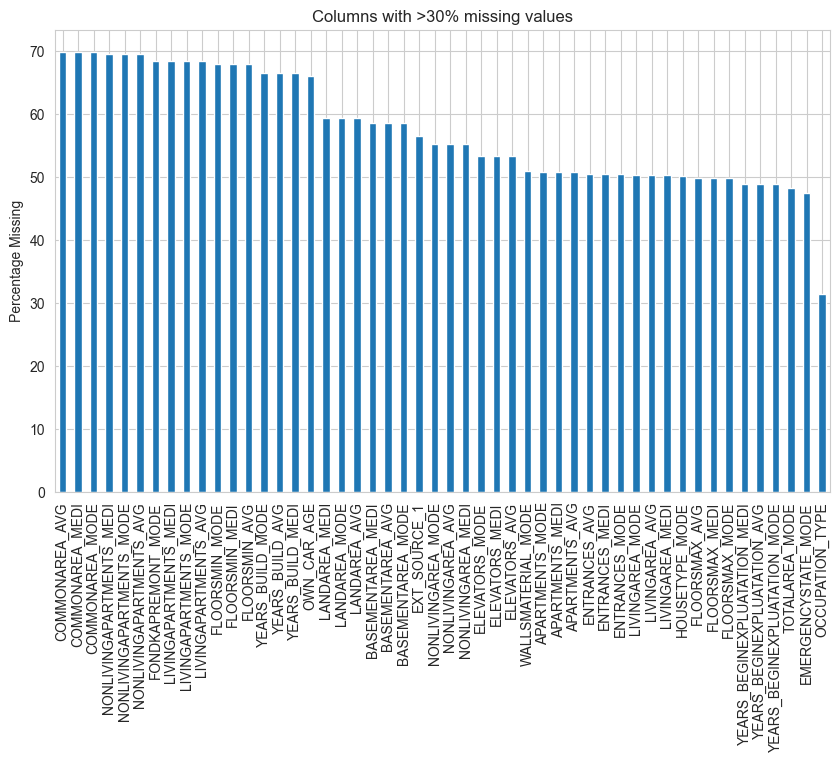

In [39]:
# Missing Values Analysis

missing = df.isnull().mean()*100
missing = missing[missing>30].sort_values(ascending = False)

plt.figure(figsize=(10,6))
missing.plot(kind = "bar")
plt.title("Columns with >30% missing values")
plt.ylabel("Percentage Missing")
plt.show()


## Insight

A significant number of columns have more than 30% missing values

These features may not be reliable for analysis and should either be:
- dropped, or
- carefully imputed based on business relevance.


In [40]:
# Split into three buckets

missing_pct = df.isnull().mean()*100

high_missing = missing_pct[missing_pct>50]
medium_missing = missing_pct[(missing_pct>10)&(missing_pct<=50)]
low_missing = missing_pct[missing_pct<=10]

print("High missing columns : ", len(high_missing))
print("Medium Missing columns : ", len(medium_missing))
print("Low missing columns : ", len(low_missing))

High missing columns :  41
Medium Missing columns :  16
Low missing columns :  65


## Insight

- High Missing (>50%) : likely to be dropped
- Medium Missing (10-50%) : candidates for imputation
- Low missing (<10%) : safe to retain

In [41]:
# Columns to drop
missing_pct = df.isnull().mean()*100

missing_pct[missing_pct>60].sort_values(ascending = False).index.tolist()

['COMMONAREA_MEDI',
 'COMMONAREA_AVG',
 'COMMONAREA_MODE',
 'NONLIVINGAPARTMENTS_MEDI',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAPARTMENTS_MODE',
 'FONDKAPREMONT_MODE',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAPARTMENTS_MEDI',
 'LIVINGAPARTMENTS_MODE',
 'FLOORSMIN_MEDI',
 'FLOORSMIN_MODE',
 'FLOORSMIN_AVG',
 'YEARS_BUILD_MEDI',
 'YEARS_BUILD_AVG',
 'YEARS_BUILD_MODE',
 'OWN_CAR_AGE']

Reason for dropping these columns:
- highly incomplete
- dont directly impact credit worthiness strongly
- are redundant (average, mode and median versions)
- Special case : OWN_CAR_AGE column is not dropped, because missing value could mean no car, so they were imputed with a special value instead of being dropped. 

In [42]:
cols_to_drop = ['COMMONAREA_MEDI',
 'COMMONAREA_AVG',
 'COMMONAREA_MODE',
 'NONLIVINGAPARTMENTS_MEDI',
 'NONLIVINGAPARTMENTS_AVG',
 'NONLIVINGAPARTMENTS_MODE',
 'FONDKAPREMONT_MODE',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAPARTMENTS_MEDI',
 'LIVINGAPARTMENTS_MODE',
 'FLOORSMIN_MEDI',
 'FLOORSMIN_MODE',
 'FLOORSMIN_AVG',
 'YEARS_BUILD_MEDI',
 'YEARS_BUILD_AVG',
 'YEARS_BUILD_MODE',
 ]
df = df.drop(columns = cols_to_drop)

In [43]:
df["OWN_CAR_AGE"] = df["OWN_CAR_AGE"].fillna(-1)

In [44]:
# Columns to impute, numerical columns were imputed with the median and categorical columns were imputed with the mode

for col in df.columns:
    if df[col].dtype != "object":
        df[col] = df[col].fillna(df[col].median)
    else:
        df[col] = df[col].fillna(df[col].mode()[0])
  

## Insight
Missing Data Handling Strategy

- Dropped columns with more than 60% missing values because of low reliability
- Treated special cases (e.g. OWN_CAR_AGE) based on domain understaning
- Imputed other missing values( moderate and low) with median and mode)

This ensures a balance between data quality and feature retention.

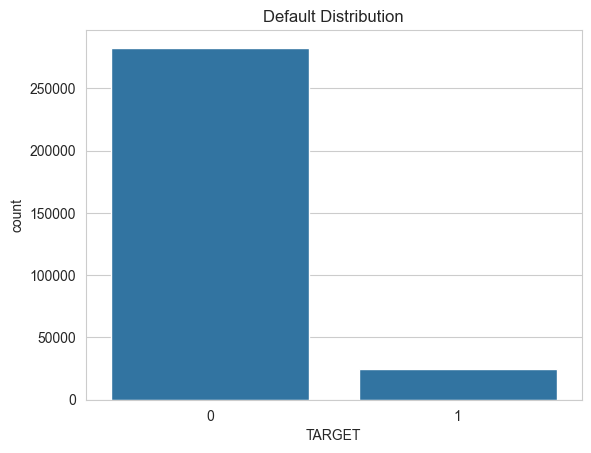

In [45]:
# Target Variable Analysis

sns.countplot(x = "TARGET", data = df)
plt.title("Default Distribution")
plt.show()

## Insight

Dataset is imbalanced. Fewer defaults compared to non-defaults.

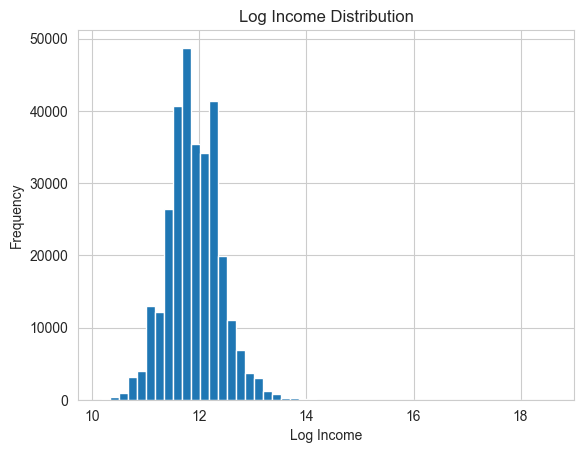

In [46]:
# Univariate Analyis
# Income Distributon

plt.figure()
plt.hist(np.log1p(df["AMT_INCOME_TOTAL"]), bins =50)
plt.title("Log Income Distribution")
plt.xlabel("Log Income")
plt.ylabel("Frequency")
plt.show()

## Insight
Income distribution is highly right skewed, log transformation reveals a more normal distribution

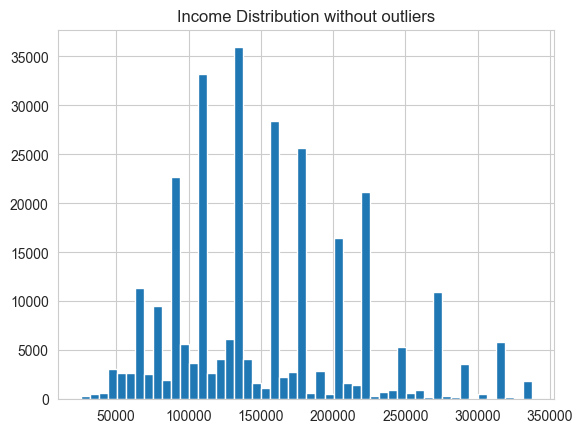

In [47]:
# Remove outliers

q1 = df["AMT_INCOME_TOTAL"].quantile(0.25)
q3 = df["AMT_INCOME_TOTAL"].quantile(0.75)

iqr = q3-q1

filtered = df[
             (df["AMT_INCOME_TOTAL"]>= q1-1.5*iqr) &
             (df["AMT_INCOME_TOTAL"]<= q3+1.5*iqr)
]
plt.figure()
plt.hist(filtered["AMT_INCOME_TOTAL"], bins = 50)
plt.title("Income Distribution without outliers")
plt.show()

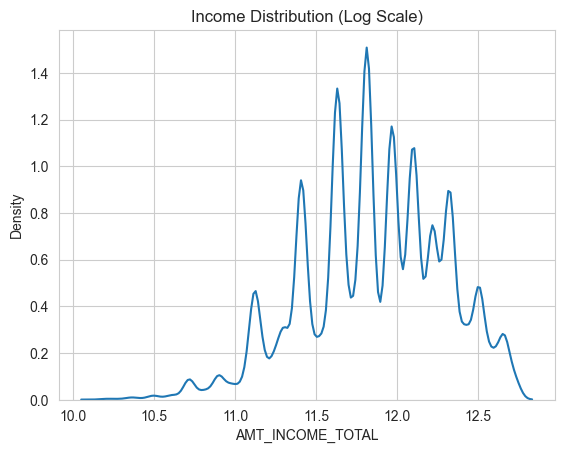

In [48]:
# Using KDE plot

sns.kdeplot(np.log1p(filtered["AMT_INCOME_TOTAL"]))
plt.title("Income Distribution (Log Scale)")
plt.show()
          

## Insight
After removing extreme outliers, income values show a clearer central tendency.

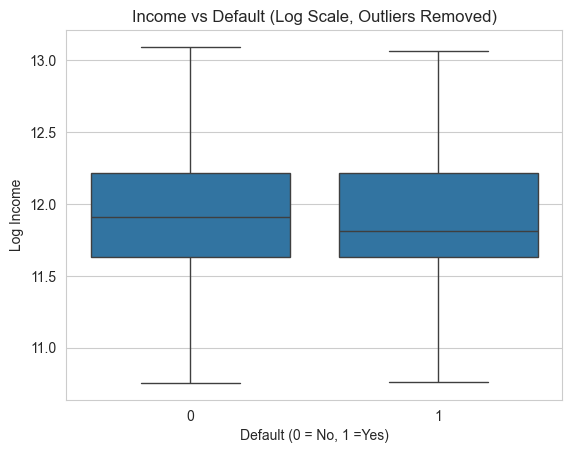

In [49]:
# Connecting to target

plt.figure()

sns.boxplot(
    x = "TARGET",
    y = np.log1p(df["AMT_INCOME_TOTAL"]),
    data = df,
    showfliers = False)

plt.title("Income vs Default (Log Scale, Outliers Removed)")
plt.xlabel("Default (0 = No, 1 =Yes)")
plt.ylabel("Log Income")

plt.show()

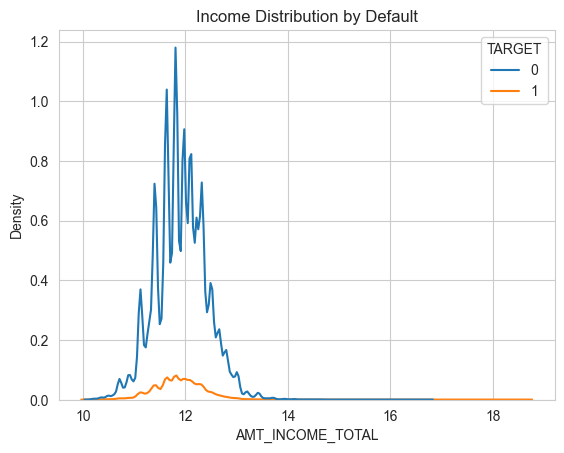

In [50]:
# Income Distribution by default KDE plot

sns.kdeplot(data = df, x = np.log1p(df["AMT_INCOME_TOTAL"]), hue = "TARGET")
plt.title("Income Distribution by Default")
plt.show()

## Insight

Income doesnt strongly differentiate between defaulters and non defaulters, as distributions strongly overlap 

In [51]:
# Correlation with target

corr = df.corr(numeric_only = True)["TARGET"].dropna()
corr.abs().sort_values(ascending = False).head(10)


TARGET                         1.000000
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
DAYS_EMPLOYED                  0.044932
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
Name: TARGET, dtype: float64

In [52]:
# Get top features

top_corr = corr.abs().sort_values(ascending = False)

# Remove weak flags
exclude = ["FLAG", "REG_CITY_NOT", "LIVE_CITY"]

top_features = [col for col in top_corr.index if not any(e in col for e in exclude)]
top_features[1:10]

['DAYS_BIRTH',
 'REGION_RATING_CLIENT_W_CITY',
 'REGION_RATING_CLIENT',
 'DAYS_ID_PUBLISH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'REGION_POPULATION_RELATIVE',
 'AMT_CREDIT',
 'HOUR_APPR_PROCESS_START']

In [53]:
# Convert columns to numeric

cols = ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [54]:
# Verify

df[cols].dtypes

EXT_SOURCE_1    float64
EXT_SOURCE_2    float64
EXT_SOURCE_3    float64
dtype: object

In [55]:
# Fill missing values with median

for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [56]:
# Top Predictors of Default

top_features = ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3','DAYS_BIRTH','DAYS_EMPLOYED']

for col in top_features:
    print(col)
    print(df.groupby("TARGET")[col].mean())
    print("\n")



EXT_SOURCE_1
TARGET
0    0.508396
1    0.457791
Name: EXT_SOURCE_1, dtype: float64


EXT_SOURCE_2
TARGET
0    0.52357
1    0.41126
Name: EXT_SOURCE_2, dtype: float64


EXT_SOURCE_3
TARGET
0    0.523767
1    0.423775
Name: EXT_SOURCE_3, dtype: float64


DAYS_BIRTH
TARGET
0   -16138.176397
1   -14884.828077
Name: DAYS_BIRTH, dtype: float64


DAYS_EMPLOYED
TARGET
0    65696.146123
1    42394.675448
Name: DAYS_EMPLOYED, dtype: float64




## Feature Selection Insight

While correlation analysis identified several variables, many were binary flags or encoded categories which can give misleading correlation values.

After combining statistical analysis with domain understanding, the most meaningful predictors were:

- External Credit Scores(EXT_SOURCE_1/2/3)
- Age (DAYS_BIRTH)
- Employment Stability (DAYS_EMPLOYED)

These features provided the strongest signal for default risk.

Defaulters consistently shows:
 - lower EXT_SOURCE scores
 - Slightly younger age
 - Less Stable Employment

## Insight

ALthough EXT_SOURCE features didnt rank highest in simple correalation analysis,
further invegiation revealed they provide strong correlation between defaulters and non-defaulters.

This highlights that correlation alone might not fully capture feature importance,
especially for non linear relationships.


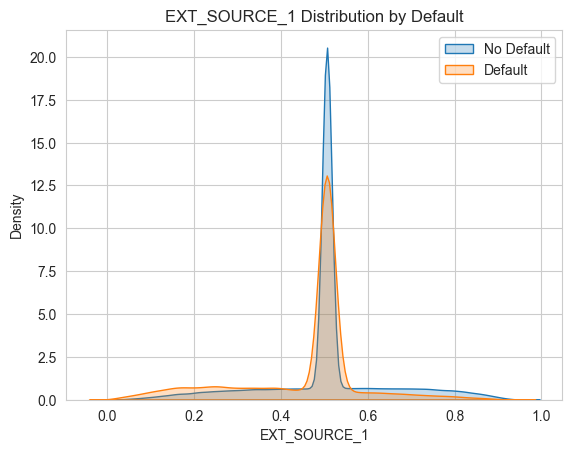

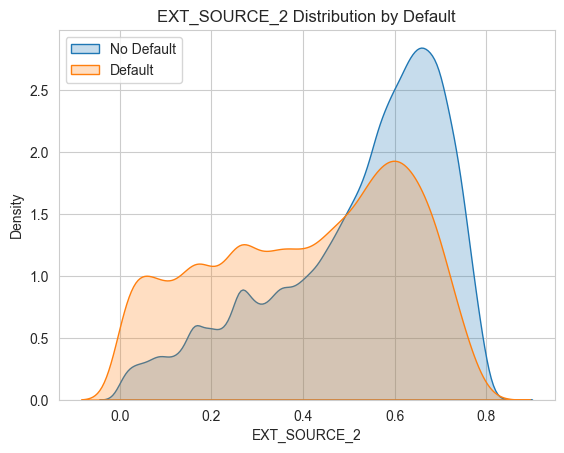

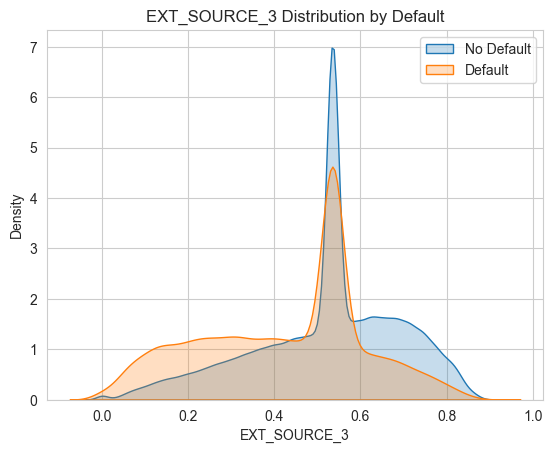

In [57]:
# Visualizing the features using KDE plots

for col in cols:
    plt.figure()
    sns.kdeplot(df[df["TARGET"]==0][col], label = "No Default", fill = True)
    sns.kdeplot(df[df["TARGET"]==1][col], label = "Default", fill = True)
    
    plt.title(f"{col} Distribution by Default")
    plt.legend()
    plt.show()

## Insight
Initial KDE plots appeared to show minimal difference due to class imbalance.

After normalizing distributions, it is evident that defaulters have consistently lower EXT_SOURCE scores.

This confirms that external credit scores are the strongest predictors of default risk.

In [59]:
# Visualization of top predictors

means = df.groupby("TARGET")[top_features].mean().T
means

TARGET,0,1
EXT_SOURCE_1,0.508396,0.457791
EXT_SOURCE_2,0.523570,0.411260
EXT_SOURCE_3,0.523767,0.423775
DAYS_BIRTH,-16138.176397,-14884.828077
DAYS_EMPLOYED,65696.146123,42394.675448


## Insight

To account for differences in feature scales, we convert everything to the same scale,
(mean = 0, std =1)

In [63]:
# Standardize features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(df[top_features]),
                         columns = top_features)
scaled["TARGET"] = df["TARGET"]
means = scaled.groupby("TARGET").mean().T
means


TARGET,0,1
EXT_SOURCE_1,0.029304,-0.333691
EXT_SOURCE_2,0.047502,-0.540912
EXT_SOURCE_3,0.046197,-0.526054
DAYS_BIRTH,-0.023186,0.264017
DAYS_EMPLOYED,0.013315,-0.151621


<Figure size 640x480 with 0 Axes>

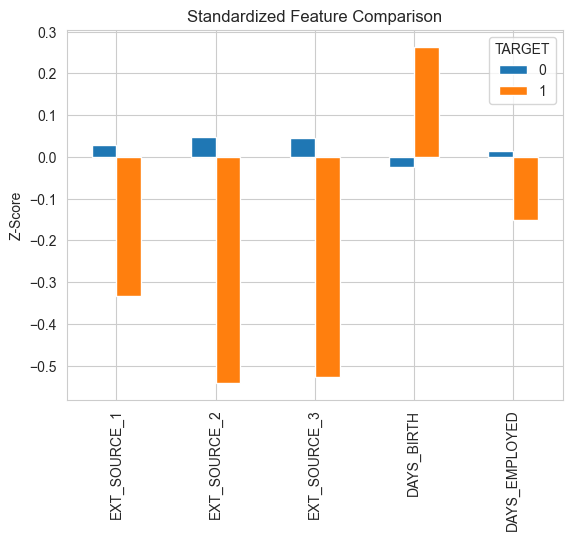

<Figure size 640x480 with 0 Axes>

In [67]:
# Visualization

plt.figure()
means.plot(kind = "bar")
plt.title("Standardized Feature Comparison")
plt.ylabel("Z-Score")
plt.show()
plt.savefig("images/top_predictors.png", bbox_inches = "tight")

##  Key Insights

- External credit scores (EXT_SOURCE_1/2/3) are the strongest predictors of default risk
- Lower scores are consistently associated with higher probability of default
- Younger applicants show slightly higher default rates
- Employment stability plays a key role in reducing risk

 Financial indicators are significantly more predictive than demographic variables


##  Business Impact

- Enables lenders to identify high-risk applicants early
- Supports data-driven loan approval decisions
- Helps reduce financial losses due to defaults
- Improves overall credit risk management strategy

 These insights can be directly used to enhance credit scoring systems

##  Conclusion

This analysis demonstrates that external credit scores and financial stability indicators are the primary drivers of loan default.

By leveraging these features, financial institutions can significantly improve risk assessment and decision-making processes.
